1. Project Setup

In [1]:
# =========================
# Imports
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import random

from pathlib import Path
import os


# =========================
# Set Random Seeds
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2. Define Project Directories

In [ ]:

PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"

for folder in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Figures folder:", FIGURES_DIR)

Project root: C:\Georgebrown\DL1\Project\project
Data folder: C:\Georgebrown\DL1\Project\project\data
Figures folder: C:\Georgebrown\DL1\Project\project\outputs\figures


In [ ]:
HAR_DIR = DATA_DIR / "UCI HAR Dataset"

print("HAR exists:", HAR_DIR.exists())
print("Files:", list(HAR_DIR.iterdir())[:10])


HAR exists: True
Files: [WindowsPath('C:/Georgebrown/DL1/Project/project/data/UCI HAR Dataset/.DS_Store'), WindowsPath('C:/Georgebrown/DL1/Project/project/data/UCI HAR Dataset/activity_labels.txt'), WindowsPath('C:/Georgebrown/DL1/Project/project/data/UCI HAR Dataset/features.txt'), WindowsPath('C:/Georgebrown/DL1/Project/project/data/UCI HAR Dataset/features_info.txt'), WindowsPath('C:/Georgebrown/DL1/Project/project/data/UCI HAR Dataset/README.txt'), WindowsPath('C:/Georgebrown/DL1/Project/project/data/UCI HAR Dataset/test'), WindowsPath('C:/Georgebrown/DL1/Project/project/data/UCI HAR Dataset/train')]


3. Load Activity Labels

In [ ]:
activity_labels_path = HAR_DIR / "activity_labels.txt"

activity_labels = pd.read_csv(
    activity_labels_path,
    sep=r"\s+",
    header=None,
    names=["id", "activity"]
)

activity_labels

,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


4. Load Training Labels

In [ ]:
y_train_path = HAR_DIR / "train" / "y_train.txt"

y_train = pd.read_csv(
    y_train_path,
    header=None,
    names=["activity_id"]
)

y_train.head()

,activity_id
0,5
1,5
2,5
3,5
4,5


5. Class Distribution (EDA)

In [ ]:
class_counts = y_train["activity_id"].value_counts().sort_index()

class_counts

activity_id
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64

In [ ]:
class_names = activity_labels.set_index("id")

class_distribution = pd.DataFrame({
    "Activity": class_names["activity"],
    "Count": class_counts.values
})

class_distribution

,Activity,Count
id,,
1,WALKING,1226
2,WALKING_UPSTAIRS,1073
3,WALKING_DOWNSTAIRS,986
4,SITTING,1286
5,STANDING,1374
6,LAYING,1407


6. Visualize Class Distribution

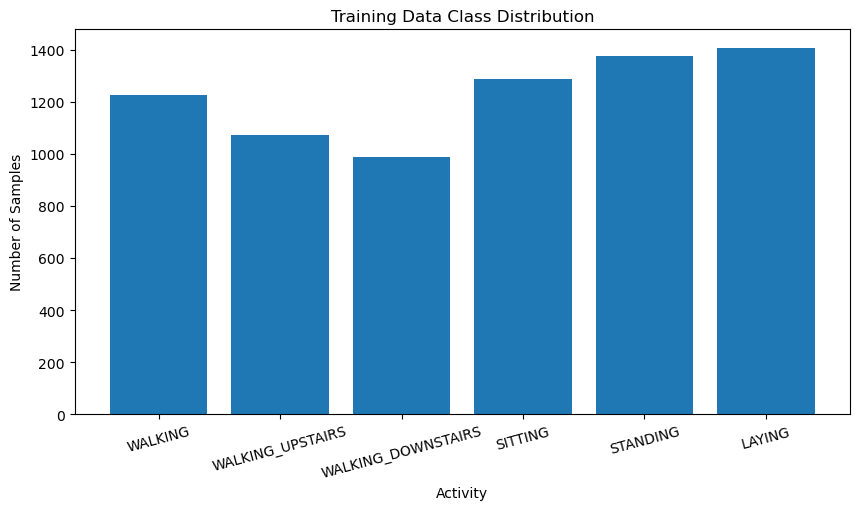

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    class_distribution["Activity"],
    class_distribution["Count"]
)

plt.title("Training Data Class Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")

plt.xticks(rotation=15)

plt.show()

7. Load Raw Sensor Signals

In [ ]:
channels = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

In [ ]:
def load_signal(signal_name, split="train"):

    signal_path = (
        HAR_DIR
        / split
        / "Inertial Signals"
        / f"{signal_name}_{split}.txt"
    )

    signal_data = np.loadtxt(signal_path)

    return signal_data

8. Load One Signal Example

In [ ]:
body_acc_x_train = load_signal("body_acc_x")

print(body_acc_x_train.shape)

(7352, 128)


9. Visualize One Raw Signal

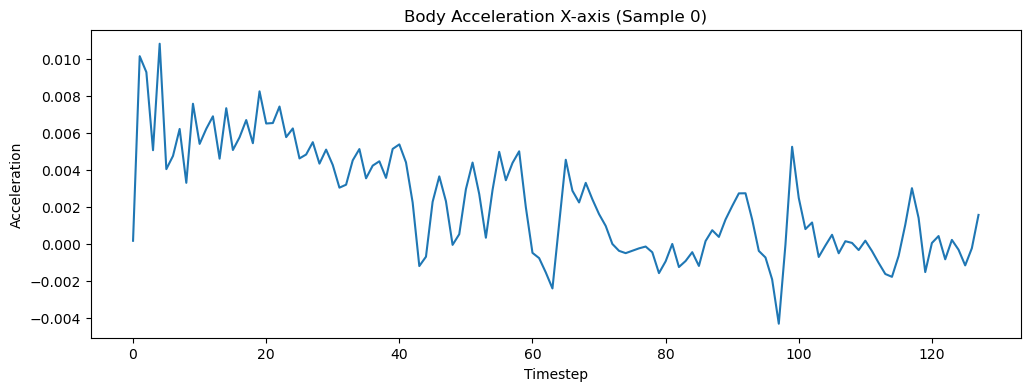

In [ ]:
sample_index = 0

plt.figure(figsize=(12,4))

plt.plot(body_acc_x_train[sample_index])

plt.title("Body Acceleration X-axis (Sample 0)")
plt.xlabel("Timestep")
plt.ylabel("Acceleration")

plt.show()

10. Compare Different Activities

In [ ]:
sample_index = 0

activity_id = y_train.iloc[sample_index, 0]

activity_name = activity_labels[
    activity_labels["id"] == activity_id
]["activity"].values[0]

print("Activity ID:", activity_id)
print("Activity Name:", activity_name)

Activity ID: 5
Activity Name: STANDING


11. Find Example Samples

In [ ]:
walking_index = y_train[y_train["activity_id"] == 1].index[0]
WALKING_UPSTAIRS_index = y_train[y_train["activity_id"] == 2].index[0]
WALKING_DOWNSTAIRS_index = y_train[y_train["activity_id"] == 3].index[0]
sitting_index = y_train[y_train["activity_id"] == 4].index[0]
STANDING_index = y_train[y_train["activity_id"] == 5].index[0]
laying_index = y_train[y_train["activity_id"] == 6].index[0]

print("Walking sample:", walking_index)
print("WALKING UPSTAIRS sample:", WALKING_UPSTAIRS_index)
print("WALKING DOWNSTAIRS sample:", WALKING_DOWNSTAIRS_index)
print("Sitting sample:", sitting_index)
print("STANDING sample:", STANDING_index)
print("Laying sample:", laying_index)

Walking sample: 78
WALKING UPSTAIRS sample: 150
WALKING DOWNSTAIRS sample: 125
Sitting sample: 27
STANDING sample: 0
Laying sample: 51


12. Compare Raw Signals

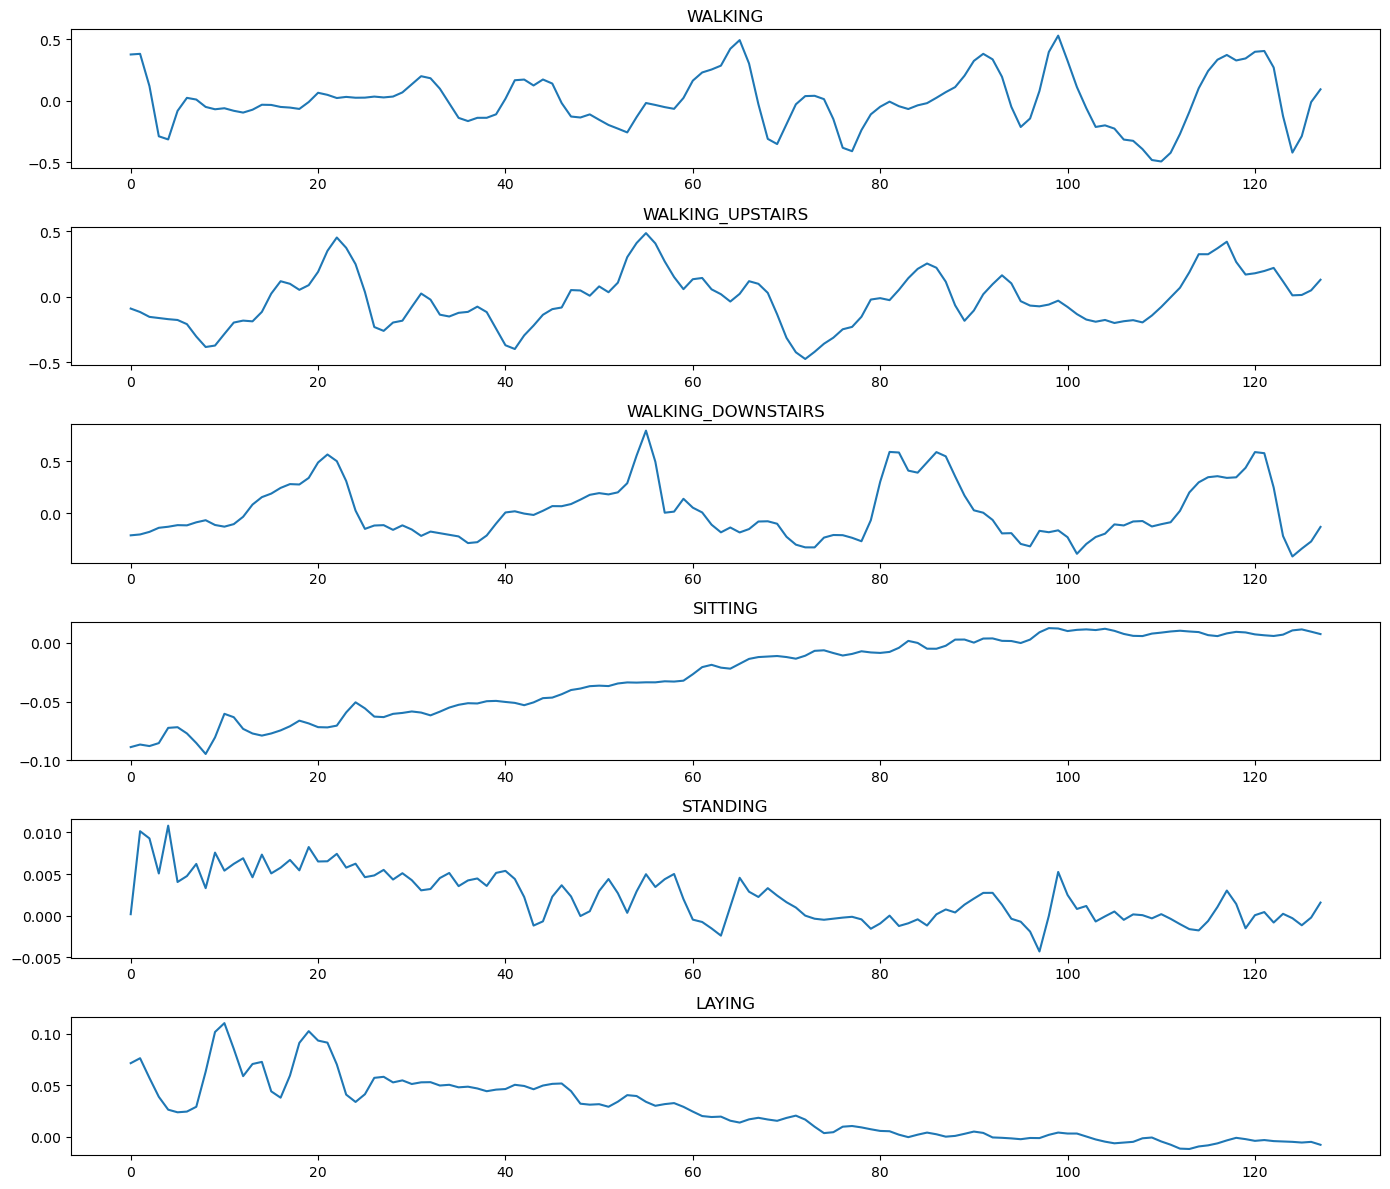

In [ ]:
plt.figure(figsize=(14,12))

plt.subplot(6,1,1)
plt.plot(body_acc_x_train[walking_index])
plt.title("WALKING")

plt.subplot(6,1,2)
plt.plot(body_acc_x_train[WALKING_UPSTAIRS_index])
plt.title("WALKING_UPSTAIRS")

plt.subplot(6,1,3)
plt.plot(body_acc_x_train[WALKING_DOWNSTAIRS_index])
plt.title("WALKING_DOWNSTAIRS")

plt.subplot(6,1,4)
plt.plot(body_acc_x_train[sitting_index])
plt.title("SITTING")

plt.subplot(6,1,5)
plt.plot(body_acc_x_train[STANDING_index])
plt.title("STANDING")

plt.subplot(6,1,6)
plt.plot(body_acc_x_train[laying_index])
plt.title("LAYING")

plt.tight_layout()

plt.show()

Load All Channels

In [ ]:
train_signals = []

for channel in channels:

    signal = load_signal(channel, split="train")

    train_signals.append(signal)

print("Number of channels:", len(train_signals))

Number of channels: 9


Stack Channels

In [ ]:
X_train = np.stack(train_signals, axis=-1)

print(X_train.shape)

(7352, 128, 9)


14. Load Test Signals

In [ ]:
test_signals = []

for channel in channels:

    signal = load_signal(channel, split="test")

    test_signals.append(signal)

print("Number of test channels:", len(test_signals))

Number of test channels: 9


15. Create X_test Tensor

In [ ]:
X_test = np.stack(test_signals, axis=-1)

print(X_test.shape)

(2947, 128, 9)


16. Load Test Labels

In [ ]:
y_test_path = HAR_DIR / "test" / "y_test.txt"

y_test = pd.read_csv(
    y_test_path,
    header=None,
    names=["activity_id"]
)

print(y_test.shape)

(2947, 1)


17. Prepare Labels for Deep Learning

In [ ]:
y_train_array = y_train["activity_id"].values - 1
y_test_array = y_test["activity_id"].values - 1

print("y_train:", y_train_array[:10])
print("y_test:", y_test_array[:10])

print("Number of classes:", len(np.unique(y_train_array)))

y_train: [4 4 4 4 4 4 4 4 4 4]
y_test: [4 4 4 4 4 4 4 4 4 4]
Number of classes: 6


18. Check Final Shapes

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train_array.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test_array.shape)

X_train: (7352, 128, 9)
y_train: (7352,)
X_test: (2947, 128, 9)
y_test: (2947,)


19. Import TensorFlow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

20. Build Baseline LSTM Model

In [ ]:

model = Sequential()

model.add(LSTM(
    units=64,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))

model.add(Dense(6, activation="softmax"))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,494 (91.77 KB)

 Trainable params: 23,494 (91.77 KB)

 Non-trainable params: 0 (0.00 B)

21. Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

22. Define Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
checkpoint_path = MODELS_DIR / "best_lstm_model.h5"

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)

23. Train Baseline LSTM Model

In [ ]:
history = model.fit(
    X_train,
    y_train_array,

    validation_split=0.2,

    epochs=20,
    batch_size=64,

    callbacks=[
        early_stop,
        model_checkpoint
    ],

    verbose=1
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3713 - loss: 1.5134

92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.4224 - loss: 1.3597 - val_accuracy: 0.4521 - val_loss: 1.2763
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5123 - loss: 1.1372

92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.5451 - loss: 1.0608 - val_accuracy: 0.6241 - val_loss: 1.0535
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6400 - loss: 0.8271

92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.6703 - loss: 0.7419 - val_accuracy: 0.7009 - val_loss: 0.8334
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7606 - loss: 0.5604

92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.7708 - loss: 0.5467 - val_accuracy: 0.7525 - val_loss: 0.8206
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8066 - loss: 0.5004

92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.8232 - loss: 0.4708 - val_accuracy: 0.7981 - val_loss: 0.6831
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8342 - loss: 0.4304

92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.8201 - loss: 0.4615 - val_accuracy: 0.8307 - val_loss: 0.6502
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8622 - loss: 0.3836

92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.8704 - loss: 0.3682 - val_accuracy: 0.8668 - val_loss: 0.5447
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.9206 - loss: 0.2352 - val_accuracy: 0.8253 - val_loss: 0.6362
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9050 - loss: 0.2565

92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.9213 - loss: 0.2261 - val_accuracy: 0.8899 - val_loss: 0.4899
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.9286 - loss: 0.2003 - val_accuracy: 0.8681 - val_loss: 0.6236
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9271 - loss: 0.1997

92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.9413 - loss: 0.1658 - val_accuracy: 0.8926 - val_loss: 0.4382
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.9080 - loss: 0.2518 - val_accuracy: 0.8919 - val_loss: 0.4921
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.9143 - loss: 0.2374 - val_accuracy: 0.8994 - val_loss: 0.6032
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.9184 - loss: 0.2242 - val_accuracy: 0.8817 - val_loss: 0.5137
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9417 - loss: 0.1565 - val_accuracy: 0.8926 - val_loss: 0.4727
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9469 - loss: 0.1426 - val_accuracy: 0.8912 - val_loss: 0.4517


In [ ]:
print("Best validation loss:", min(history.history["val_loss"]))
print("Best validation accuracy:", max(history.history["val_accuracy"]))

Best validation loss: 0.43815743923187256
Best validation accuracy: 0.8993881940841675


24. Plot Training History

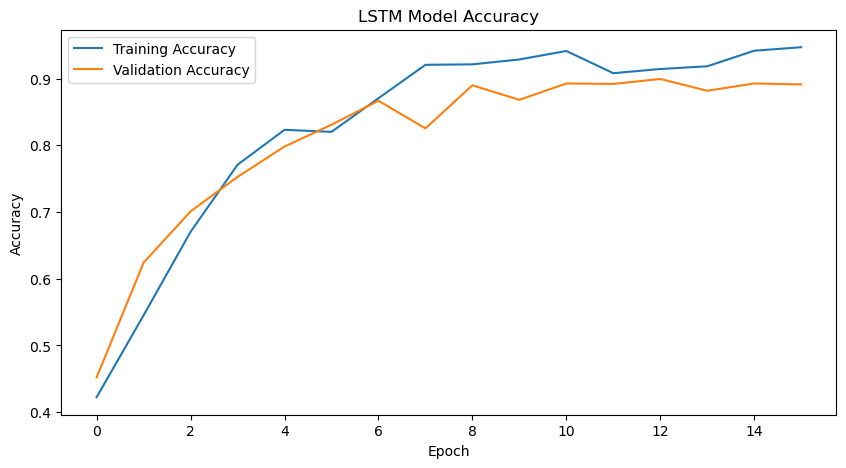

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    FIGURES_DIR / "lstm_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

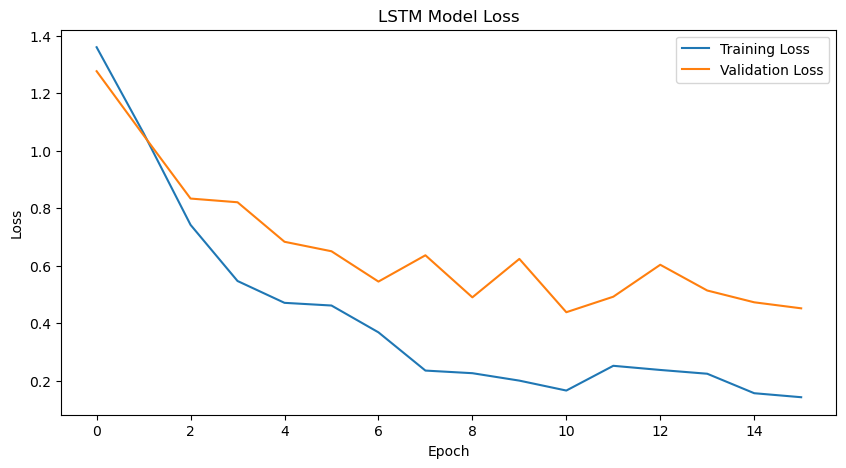

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    FIGURES_DIR / "lstm_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### The model achieved approximately 90% validation accuracy. Validation loss began increasing after later epochs, indicating signs of overfitting. EarlyStopping and ModelCheckpoint callbacks were used to preserve the best-performing model.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_array
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8897 - loss: 0.5091
Test Loss: 0.5090622901916504
Test Accuracy: 0.8897183537483215


25. Generate Predictions

In [ ]:
y_pred_probs = model.predict(X_test)

print(y_pred_probs.shape)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
(2947, 6)


26. Convert Probabilities to Class Labels

In [ ]:
y_pred = np.argmax(y_pred_probs, axis=1)

print(y_pred[:10])

[4 4 4 4 4 4 4 4 4 4]


27. Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(y_test_array, y_pred)

print(cm)

[[485   2   9   0   0   0]
 [ 63 396  11   0   1   0]
 [ 10  24 386   0   0   0]
 [  5   0   2 375 109   0]
 [  1   0   0  59 472   0]
 [  0  27   2   0   0 508]]


28. Visualize Confusion Matrix

<Figure size 1000x800 with 0 Axes>

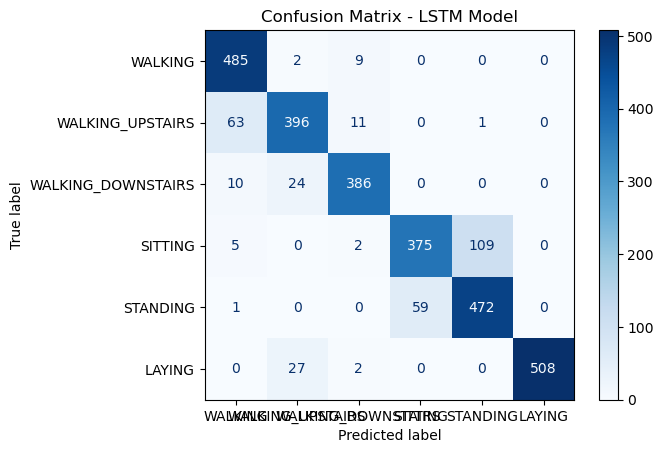

In [ ]:
activity_names = activity_labels["activity"].tolist()

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=activity_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - LSTM Model")

plt.savefig(
    FIGURES_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### The confusion matrix shows that dynamic activities such as walking and laying were classified accurately, while static activities such as sitting and standing were more difficult to distinguish due to similar sensor patterns.

### This project demonstrates how deep learning can extract temporal behavioral patterns from wearable sensor data, forming a foundation for future intelligent healthcare systems.

29. Classification Report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
report = classification_report(
    y_test_array,
    y_pred,
    target_names=activity_labels["activity"].tolist()
)

print(report)

                    precision    recall  f1-score   support

           WALKING       0.86      0.98      0.92       496
  WALKING_UPSTAIRS       0.88      0.84      0.86       471
WALKING_DOWNSTAIRS       0.94      0.92      0.93       420
           SITTING       0.86      0.76      0.81       491
          STANDING       0.81      0.89      0.85       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.89      2947
         macro avg       0.89      0.89      0.89      2947
      weighted avg       0.89      0.89      0.89      2947



### The model classified general human movements (dynamic activities) effectively. However, distinguishing between walking, walking upstairs, and walking downstairs was more challenging due to similarities in their motion patterns. Similarly, sitting and standing, which are both relatively static activities, were more difficult to separate because of comparable inertial sensor characteristics. In contrast, the laying activity (static activity) was recognized very accurately due to its distinct body orientation and sensor pattern.

31. Build CNN-LSTM Hybrid Model

In [ ]:
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D

In [ ]:
cnn_lstm_model = Sequential()

cnn_lstm_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

cnn_lstm_model.add(MaxPooling1D(pool_size=2))

cnn_lstm_model.add(LSTM(64))

cnn_lstm_model.add(Dropout(0.3))

cnn_lstm_model.add(Dense(64, activation="relu"))

cnn_lstm_model.add(Dense(6, activation="softmax"))

cnn_lstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,366 (153.77 KB)

 Trainable params: 39,366 (153.77 KB)

 Non-trainable params: 0 (0.00 B)

32. Compile CNN-LSTM Model

In [ ]:
cnn_lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

33. Define CNN-LSTM Callbacks

In [ ]:
cnn_lstm_checkpoint_path = MODELS_DIR / "best_cnn_lstm_model.keras"

cnn_lstm_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

cnn_lstm_checkpoint = ModelCheckpoint(
    filepath=cnn_lstm_checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)

34. Train CNN-LSTM Model

In [ ]:
cnn_lstm_history = cnn_lstm_model.fit(
    X_train,
    y_train_array,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[
        cnn_lstm_early_stop,
        cnn_lstm_checkpoint
    ],
    verbose=1
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5579 - loss: 0.9993 - val_accuracy: 0.7410 - val_loss: 0.6597
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7761 - loss: 0.5022 - val_accuracy: 0.8389 - val_loss: 0.5210
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.8835 - loss: 0.3149 - val_accuracy: 0.8668 - val_loss: 0.3978
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9107 - loss: 0.2479 - val_accuracy: 0.8783 - val_loss: 0.3633
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9240 - loss: 0.2116 - val_accuracy: 0.8872 - val_loss: 0.3361
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9395 - loss: 0.1629 - val_accuracy: 0.9103 - val_loss: 0.2982
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9442 - loss: 0.1442 - val_accuracy: 0.9096 - val_loss: 0.3070
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9476 - loss: 0.1266 - val_accuracy: 0.9130 - v

35. Evaluate CNN-LSTM Model

In [ ]:
cnn_lstm_test_loss, cnn_lstm_test_accuracy = cnn_lstm_model.evaluate(
    X_test,
    y_test_array
)

print("CNN-LSTM Test Loss:", cnn_lstm_test_loss)
print("CNN-LSTM Test Accuracy:", cnn_lstm_test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8846 - loss: 0.4681
CNN-LSTM Test Loss: 0.4680866003036499
CNN-LSTM Test Accuracy: 0.884628415107727


In [ ]:
print("Best CNN-LSTM validation loss:", min(cnn_lstm_history.history["val_loss"]))
print("Best CNN-LSTM validation accuracy:", max(cnn_lstm_history.history["val_accuracy"]))

Best CNN-LSTM validation loss: 0.2981801927089691
Best CNN-LSTM validation accuracy: 0.9129843711853027


### The CNN-LSTM model achieved higher validation accuracy and lower test loss compared to the baseline LSTM, but its final test accuracy was slightly lower. This suggests that the hybrid model learned stronger temporal-feature representations, although it did not significantly improve generalization on the unseen test set.

36. Generate CNN-LSTM Predictions

In [ ]:
cnn_lstm_y_pred_probs = cnn_lstm_model.predict(X_test)

cnn_lstm_y_pred = np.argmax(
    cnn_lstm_y_pred_probs,
    axis=1
)

print(cnn_lstm_y_pred_probs.shape)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
(2947, 6)


In [ ]:
cnn_lstm_y_pred = np.argmax(
    cnn_lstm_y_pred_probs,
    axis=1
)

print(cnn_lstm_y_pred[:10])

[4 4 4 4 4 4 4 4 4 4]


37. CNN-LSTM Classification Report

In [ ]:
cnn_lstm_report = classification_report(
    y_test_array,
    cnn_lstm_y_pred,
    target_names=activity_labels["activity"].tolist()
)

print(cnn_lstm_report)

                    precision    recall  f1-score   support

           WALKING       0.90      0.93      0.91       496
  WALKING_UPSTAIRS       0.86      0.87      0.87       471
WALKING_DOWNSTAIRS       0.85      0.92      0.88       420
           SITTING       0.80      0.85      0.82       491
          STANDING       0.89      0.79      0.84       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.88      2947
         macro avg       0.88      0.89      0.88      2947
      weighted avg       0.89      0.88      0.88      2947



38. CNN-LSTM Confusion Matrix

In [ ]:
cnn_lstm_cm = confusion_matrix(
    y_test_array,
    cnn_lstm_y_pred
)

print(cnn_lstm_cm)

[[462   3  31   0   0   0]
 [ 22 412  37   0   0   0]
 [ 24  10 386   0   0   0]
 [  1  23   0 416  51   0]
 [  6   2   0 103 421   0]
 [  0  27   0   0   0 510]]


39. Visualize CNN-LSTM Confusion Matrix

<Figure size 1000x800 with 0 Axes>

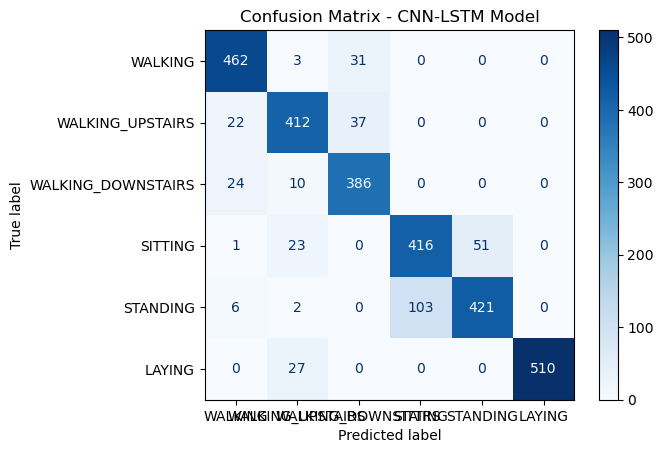

In [ ]:
plt.figure(figsize=(10,8))

cnn_lstm_disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_lstm_cm,
    display_labels=activity_labels["activity"].tolist()
)

cnn_lstm_disp.plot(cmap="Blues")

plt.title("Confusion Matrix - CNN-LSTM Model")

plt.savefig(
    FIGURES_DIR / "cnn_lstm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### The CNN-LSTM model improved recognition of certain static activities such as sitting, likely due to enhanced local feature extraction by the convolutional layers. However, confusion between sitting and standing remained significant, and some dynamic activities such as walking and walking downstairs became more difficult to distinguish.

### While the CNN-LSTM model improved certain local feature representations, it also introduced confusion between dynamic and static activities that was less apparent in the baseline LSTM model. This suggests that convolutional pooling may reduce some temporal distinctions necessary for separating low-motion and high-motion behaviors.

### Although the CNN-LSTM model achieved a slightly higher validation accuracy (91.3%) compared to the baseline LSTM model (approximately 90%), its real-world classification behavior was less reliable in some cases. The baseline LSTM achieved a higher test accuracy of approximately 88.97%, while the CNN-LSTM achieved about 88.46%. More importantly, the CNN-LSTM introduced additional confusion between dynamic and static activities, such as misclassifying standing and sitting with movement-related activities. In contrast, the baseline LSTM preserved temporal distinctions more effectively and produced more consistent activity separation. These results suggest that a higher validation accuracy does not necessarily indicate better practical classification performance or behavioral interpretability.

Create Comparison DataFrame

In [ ]:
comparison_df = pd.DataFrame({

    "Model": [
        "Baseline LSTM",
        "CNN-LSTM"
    ],

    "Validation Accuracy": [
        0.899,
        0.913
    ],

    "Test Accuracy": [
        0.889,
        0.885
    ],

    "Key Observation": [
        "Better temporal separation",
        "Higher validation accuracy but more confusion between static and dynamic activities"
    ]
})

comparison_df

,Model,Validation Accuracy,Test Accuracy,Key Observation
0,Baseline LSTM,0.899,0.889,Better temporal separation
1,CNN-LSTM,0.913,0.885,Higher validation accuracy but more confusion ...


In [ ]:
comparison_df.to_csv(
    OUTPUTS_DIR / "model_comparison.csv",
    index=False
)